# Fake Job Posting Detection — Replicating Two EMSCAD Papers

This notebook replicates the techniques from two papers evaluated on the **EMSCAD** (Employment Scam Aegean Dataset):

1. **"A Comparative Study on Fake Job Post Prediction Using Different Data Mining Techniques"** (Habiba et al., ICREST 2021) — trains KNN, Random Forest, Decision Tree, SVM, Naive Bayes and MLP on the **categorical** attributes only (`telecommuting`, `has_company_logo`, `has_questions`, `employment_type`, `required_experience`, `required_education`), reporting ~97% accuracy with Random Forest and a 10-fold DNN at ~97.7% average.
2. **"Fake Job Prediction using Sequential Network"** (ICIIS 2020) — does EDA (word clouds, word-count histograms), cleans the **text** fields, embeds them with pretrained **GloVe** vectors, balances classes with SMOTE, then trains a small `Sequential` Dense network.

On top of replicating both, this notebook adds the things neither paper bothers with end-to-end: proper missing-value handling, engineered features beyond the raw categoricals, a side-by-side imbalance comparison (raw vs. class-weighted vs. SMOTE), and a single inference pipeline that takes a raw job posting dict and returns a fraud probability.

**Dataset:** `fake_job_postings.csv` — 17,880 rows, 18 columns, 866 fraudulent (4.8%) / 17,014 real (95.2%) — matches the EMSCAD counts both papers report.

**Environment:** built and run on Google Colab (GPU runtime). The GloVe download in Section 8 is ~800MB, so the first run of that cell takes a few minutes.


## 1. Setup

Core libraries: `pandas`, `numpy`, `scikit-learn`, `imbalanced-learn` (SMOTE), `tensorflow`/`keras`, `wordcloud`, `matplotlib`, `seaborn`. All ship with the Colab runtime except `wordcloud` and `imbalanced-learn`, which install in seconds via `pip install wordcloud imbalanced-learn` if missing.


In [1]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS as WC_STOPWORDS

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_auc_score)

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid')


## 2. Load the data



In [2]:
df = pd.read_csv('fake_job_postings.csv')
print(df.shape)
df.head(3)

(17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [4]:
print(df['fraudulent'].value_counts())
print(df['fraudulent'].value_counts(normalize=True).round(4) * 100)

fraudulent
0    17014
1      866
Name: count, dtype: int64
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
salary_range,15012,84.0
department,11547,64.6
required_education,8105,45.3
benefits,7212,40.3
required_experience,7050,39.4
function,6455,36.1
industry,4903,27.4
employment_type,3471,19.4
company_profile,3308,18.5
requirements,2696,15.1


## 3. Exploratory Data Analysis

Reproducing the EDA from the "Sequential Network" paper: class balance, correlation of the binary flags with the target, word clouds for real vs. fake posts, and word-count histograms.

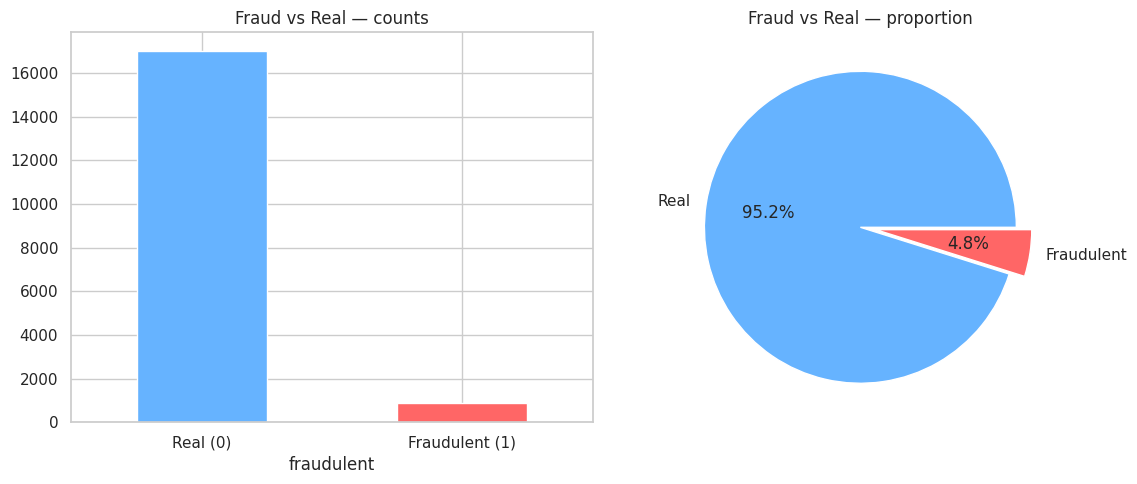

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df['fraudulent'].value_counts().plot(kind='bar', ax=ax[0], color=['#66b3ff', '#ff6666'])
ax[0].set_xticklabels(['Real (0)', 'Fraudulent (1)'], rotation=0)
ax[0].set_title('Fraud vs Real — counts')

df['fraudulent'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[1],
                                      labels=['Real', 'Fraudulent'], colors=['#66b3ff', '#ff6666'],
                                      explode=[0, 0.1])
ax[1].set_ylabel('')
ax[1].set_title('Fraud vs Real — proportion')
plt.tight_layout()
plt.show()

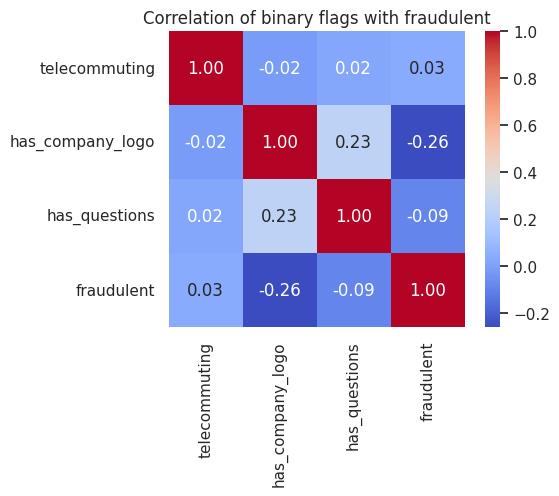

fraudulent          1.000000
telecommuting       0.034523
has_questions      -0.091627
has_company_logo   -0.261971
Name: fraudulent, dtype: float64


In [7]:
corr_cols = ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
corr = df[corr_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation of binary flags with fraudulent')
plt.tight_layout()
plt.show()
print(corr['fraudulent'].sort_values(ascending=False))

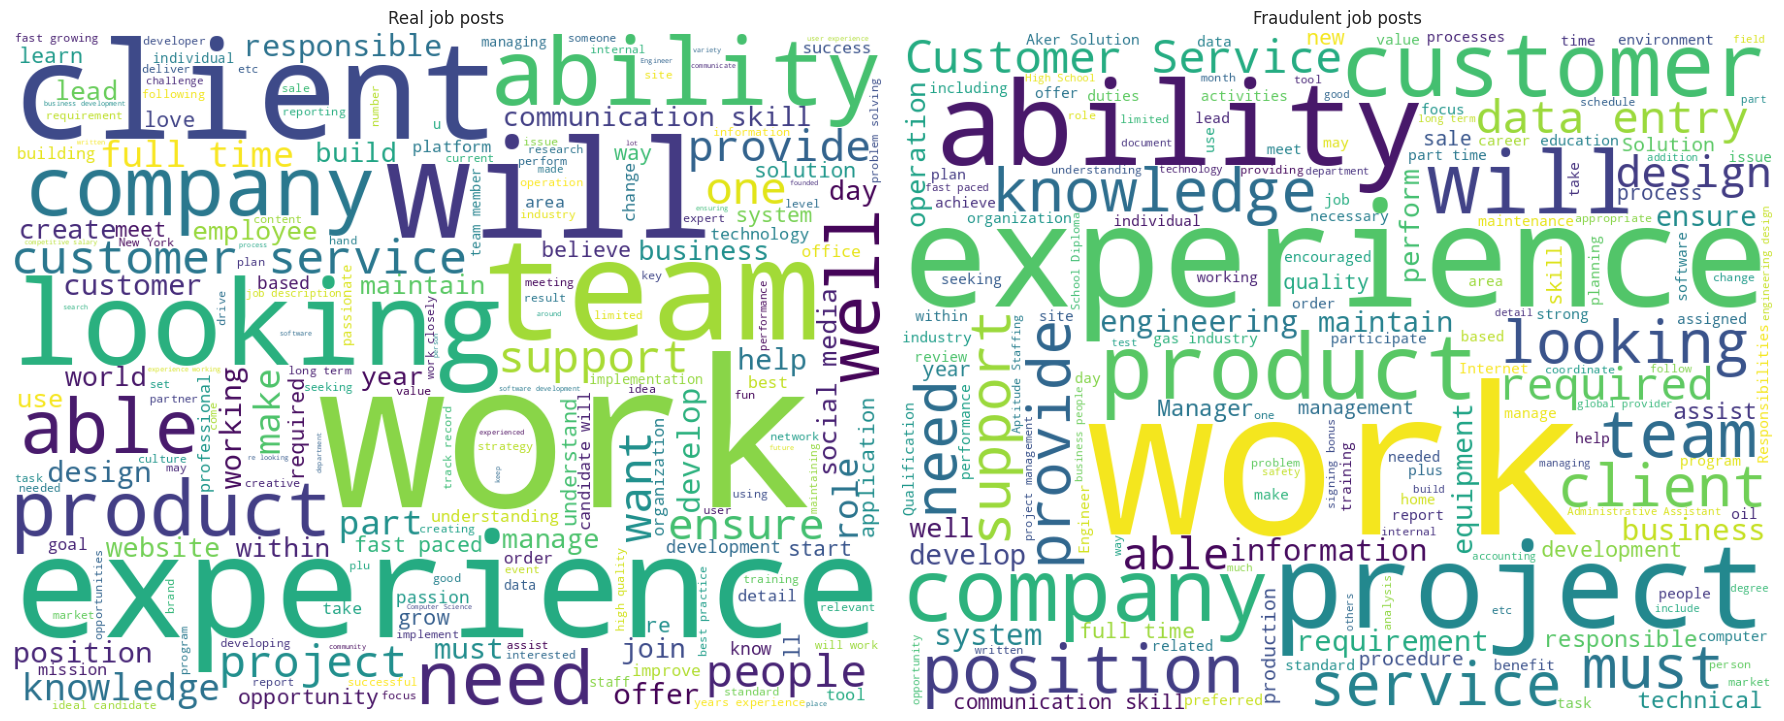

In [8]:
# Combine all text fields the way the paper does, for the word clouds / histograms only
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
combined_text = df[text_cols].fillna('').agg(' '.join, axis=1)

real_text = combined_text[df['fraudulent'] == 0]
fraud_text = combined_text[df['fraudulent'] == 1]

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
wc_real = WordCloud(width=900, height=700, stopwords=WC_STOPWORDS, background_color='white').generate(' '.join(real_text))
wc_fraud = WordCloud(width=900, height=700, stopwords=WC_STOPWORDS, background_color='white').generate(' '.join(fraud_text))
ax[0].imshow(wc_real); ax[0].axis('off'); ax[0].set_title('Real job posts')
ax[1].imshow(wc_fraud); ax[1].axis('off'); ax[1].set_title('Fraudulent job posts')
plt.tight_layout()
plt.show()

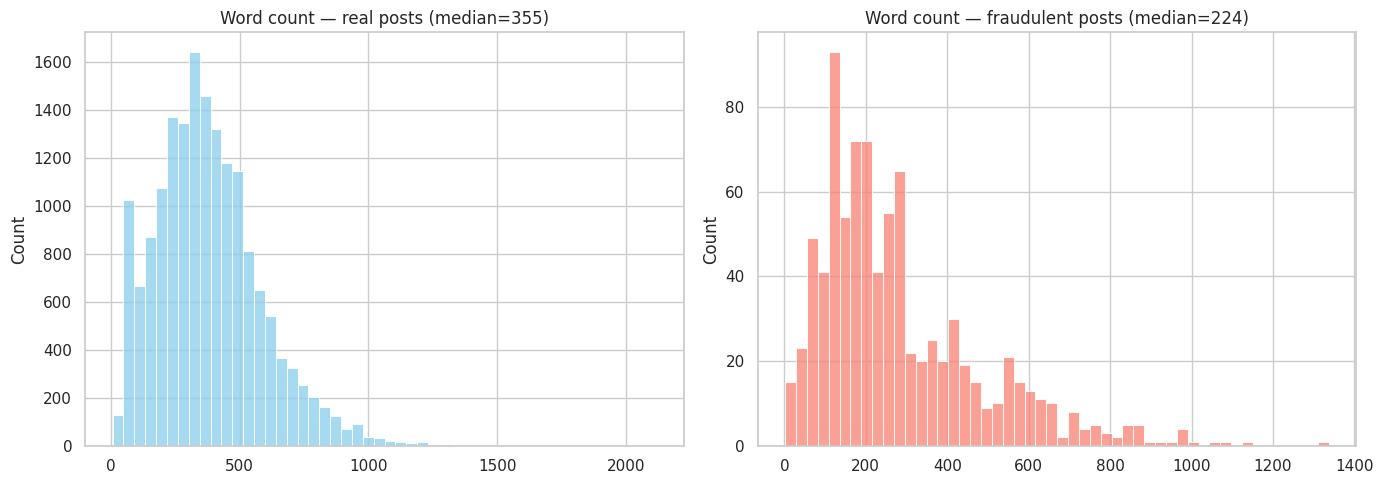

In [9]:
real_wc = real_text.apply(lambda t: len(t.split()))
fraud_wc = fraud_text.apply(lambda t: len(t.split()))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(real_wc, bins=50, ax=ax[0], color='skyblue')
ax[0].set_title(f'Word count — real posts (median={int(real_wc.median())})')
sns.histplot(fraud_wc, bins=50, ax=ax[1], color='salmon')
ax[1].set_title(f'Word count — fraudulent posts (median={int(fraud_wc.median())})')
plt.tight_layout()
plt.show()

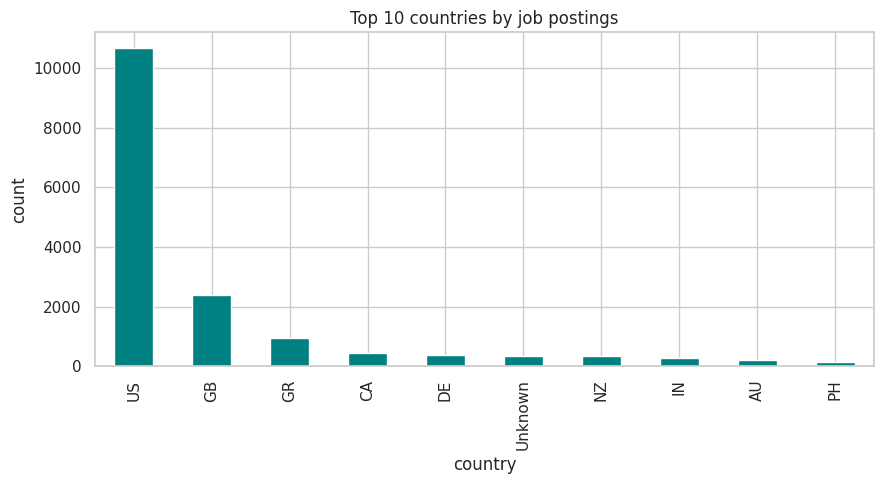

In [10]:
def country(loc):
    if pd.isna(loc):
        return 'Unknown'
    return loc.split(',')[0].strip()

df['country'] = df['location'].apply(country)
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(9, 5))
top_countries.plot(kind='bar', color='teal')
plt.title('Top 10 countries by job postings')
plt.ylabel('count')
plt.tight_layout()
plt.show()

## 4. Feature engineering

Two feature sets, since the two papers use two different representations:

- **Structural/categorical features** (paper 1's approach): the flags plus ordinal-encoded `employment_type`, `required_experience`, `required_education`, extended here with a few engineered signals the paper doesn't use — presence/absence of salary, company profile, and requirements, since scam posts are more likely to omit these.
- **Text features** (paper 2's approach): all free-text fields concatenated and cleaned, then either TF-IDF (used for the classic ML models) or a Keras `Tokenizer`+`Embedding` sequence (used for the Sequential network).

Missing categorical text (e.g. no `employment_type` given) is treated as its own category rather than dropped — an empty field is itself a signal for scam detection, not noise to discard.

In [11]:
data = df.copy()

# --- engineered binary "presence" features ---
data['has_salary'] = data['salary_range'].notna().astype(int)
data['has_company_profile'] = data['company_profile'].notna().astype(int)
data['has_requirements'] = data['requirements'].notna().astype(int)
data['has_benefits'] = data['benefits'].notna().astype(int)
data['has_department'] = data['department'].notna().astype(int)

# --- text length features ---
combined_text_all = data[text_cols].fillna('').agg(' '.join, axis=1)
data['text_length'] = combined_text_all.apply(lambda t: len(t.split()))
data['title_length'] = data['title'].fillna('').apply(lambda t: len(t.split()))

# --- fill categorical text with an explicit "Not Provided" category (paper 1's approach) ---
for c in ['employment_type', 'required_experience', 'required_education']:
    data[c] = data[c].fillna('Not Provided')

data[['has_salary', 'has_company_profile', 'has_requirements', 'has_benefits',
      'has_department', 'text_length', 'title_length']].describe()

,has_salary,has_company_profile,has_requirements,has_benefits,has_department,text_length,title_length
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,0.160403,0.814989,0.849217,0.596644,0.354195,374.785291,3.761913
std,0.366989,0.388317,0.357847,0.490585,0.478282,207.615353,2.074126
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
25%,0.000000,1.000000,1.000000,0.000000,0.000000,229.000000,2.000000
50%,0.000000,1.000000,1.000000,1.000000,0.000000,349.000000,3.000000
75%,0.000000,1.000000,1.000000,1.000000,1.000000,492.000000,5.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,2118.000000,19.000000


In [12]:
# Ordinal encodings, same mappings as the paper (domain-ordered, not arbitrary label encoding)
employment_type_mapping = {
    'Not Provided': 0, 'Full-time': 1, 'Part-time': 2, 'Other': 3, 'Contract': 4, 'Temporary': 5
}
experience_mapping = {
    'Not Provided': 0, 'Not Applicable': 1, 'Internship': 2, 'Entry level': 3,
    'Associate': 4, 'Mid-Senior level': 5, 'Director': 6, 'Executive': 7
}
education_mapping = {
    'Not Provided': 0, 'Unspecified': 1, 'Some High School Coursework': 2,
    'Vocational - HS Diploma': 3, 'High School or equivalent': 4,
    'Some College Coursework Completed': 5, 'Vocational': 6, 'Certification': 7,
    'Associate Degree': 8, "Bachelor's Degree": 9, 'Vocational - Degree': 10,
    "Master's Degree": 11, 'Professional': 12, 'Doctorate': 13
}
data['required_education'] = data['required_education'].fillna('Not Provided')
data['employment_type_enc'] = data['employment_type'].map(employment_type_mapping).fillna(0).astype(int)
data['required_experience_enc'] = data['required_experience'].map(experience_mapping).fillna(0).astype(int)
data['required_education_enc'] = data['required_education'].map(education_mapping).fillna(0).astype(int)

structural_features = ['telecommuting', 'has_company_logo', 'has_questions',
                        'employment_type_enc', 'required_experience_enc', 'required_education_enc',
                        'has_salary', 'has_company_profile', 'has_requirements', 'has_benefits',
                        'has_department', 'text_length', 'title_length']

X_struct = data[structural_features]
y = data['fraudulent']
X_struct.head()

,telecommuting,has_company_logo,has_questions,employment_type_enc,required_experience_enc,required_education_enc,has_salary,has_company_profile,has_requirements,has_benefits,has_department,text_length,title_length
0,0,1,0,3,2,0,0,1,1,0,1,382,2
1,0,1,0,1,1,0,0,1,1,1,1,901,6
2,0,1,0,0,0,0,0,1,1,0,0,359,4
3,0,1,0,1,5,9,0,1,1,1,1,709,5
4,0,1,1,1,5,9,0,1,1,1,0,470,3


In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\S+@\S+', ' ', text)          # emails
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # urls
    text = re.sub(r'#url_[a-z0-9]+#', ' ', text)   # EMSCAD's #URL_...# placeholders
    text = re.sub(r'[^a-z\s]', ' ', text)          # punctuation / digits
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['clean_text'] = combined_text_all.apply(clean_text)
data[['clean_text']].head(2)

,clean_text
0,marketing intern we re food and we ve created ...
1,customer service cloud video production second...


## 5. Class imbalance

Only 4.8% of postings are fraudulent — same skew both papers report (paper 2 finds 866 fake / 17,014 real, matching exactly). Both papers reach for SMOTE; we compare that against plain training and class-weighting so the choice isn't just cargo-culted from the papers.

In [14]:
print('Class balance:')
print(y.value_counts(normalize=True).round(4) * 100)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_struct, y, test_size=0.2, stratify=y, random_state=SEED)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')
print('Train class balance:', y_train_s.value_counts().to_dict())

Class balance:
fraudulent
0    95.16
1     4.84
Name: proportion, dtype: float64
Train: (14304, 13), Test: (3576, 13)
Train class balance: {0: 13611, 1: 693}


In [15]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train_s)
print('Before SMOTE:', y_train_s.value_counts().to_dict())
print('After SMOTE :', y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 13611, 1: 693}
After SMOTE : {0: 13611, 1: 13611}


## 6. Paper 1 replication — classical ML on structural features

KNN (with the paper's k-sweep to find the elbow), Random Forest, Decision Tree, SVM (RBF kernel, gamma=0.001 as specified), Naive Bayes and MLP — each trained three ways (raw, class-weighted where supported, SMOTE-balanced) so the imbalance-handling choice is visible in the results rather than assumed.

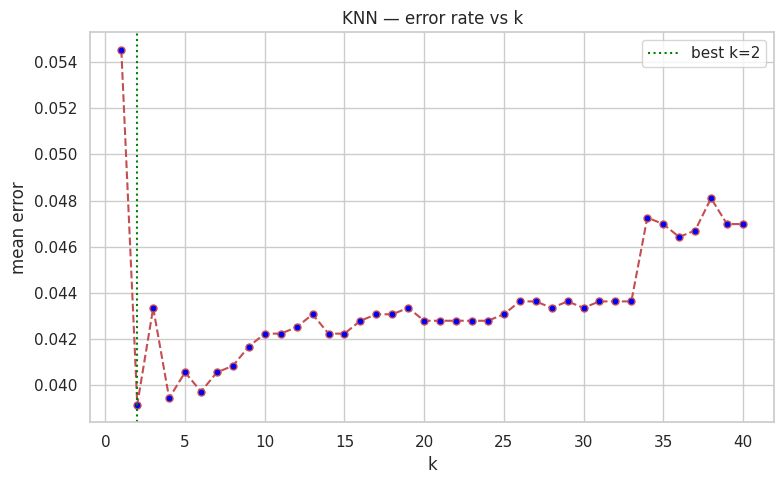

best_k = 2


In [16]:
error_rates = []
k_range = range(1, 41)
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train_s)
    pred = knn.predict(X_test_s)
    error_rates.append(np.mean(pred != y_test_s))

best_k = list(k_range)[int(np.argmin(error_rates))]
plt.figure(figsize=(8, 5))
plt.plot(k_range, error_rates, 'r--', marker='o', markerfacecolor='blue', markersize=5)
plt.axvline(best_k, color='green', linestyle=':', label=f'best k={best_k}')
plt.title('KNN — error rate vs k')
plt.xlabel('k'); plt.ylabel('mean error'); plt.legend()
plt.tight_layout()
plt.show()
print('best_k =', best_k)

In [17]:
def evaluate(name, y_true, y_pred, results_list):
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    results_list.append(row)
    return row

results_raw, results_weighted, results_smote = [], [], []

model_specs = {
    'KNN': lambda: KNeighborsClassifier(n_neighbors=best_k),
    'Random Forest': lambda: RandomForestClassifier(random_state=SEED),
    'Decision Tree': lambda: DecisionTreeClassifier(random_state=SEED),
    'SVM (RBF)': lambda: SVC(kernel='rbf', gamma=0.001),
    'Naive Bayes': lambda: GaussianNB(),
    'MLP': lambda: MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED),
}
weighted_supported = {'Random Forest', 'Decision Tree', 'SVM (RBF)', 'MLP'}

for name, ctor in model_specs.items():
    # raw
    m = ctor()
    m.fit(X_train_s, y_train_s)
    evaluate(name, y_test_s, m.predict(X_test_s), results_raw)

    # class-weighted (only where sklearn supports it cleanly)
    if name in weighted_supported:
        m_w = ctor()
        if hasattr(m_w, 'class_weight'):
            m_w.set_params(class_weight='balanced')
        m_w.fit(X_train_s, y_train_s)
        evaluate(name, y_test_s, m_w.predict(X_test_s), results_weighted)

    # SMOTE
    m_s = ctor()
    m_s.fit(X_train_smote, y_train_smote)
    evaluate(name, y_test_s, m_s.predict(X_test_s), results_smote)

df_raw = pd.DataFrame(results_raw).set_index('Model').round(4)
df_weighted = pd.DataFrame(results_weighted).set_index('Model').round(4)
df_smote = pd.DataFrame(results_smote).set_index('Model').round(4)

print('--- Raw (imbalanced) ---'); display(df_raw)
print('--- Class-weighted ---'); display(df_weighted)
print('--- SMOTE-balanced ---'); display(df_smote)

--- Raw (imbalanced) ---


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9609,0.7619,0.2775,0.4068
Random Forest,0.9690,0.7672,0.5145,0.6159
Decision Tree,0.9567,0.5517,0.5549,0.5533
SVM (RBF),0.9516,0.0000,0.0000,0.0000
Naive Bayes,0.8747,0.2117,0.5838,0.3108
MLP,0.9463,0.4228,0.3006,0.3514


--- Class-weighted ---


,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest,0.9692,0.7692,0.5202,0.6207
Decision Tree,0.9561,0.5471,0.5376,0.5423
SVM (RBF),0.7855,0.1351,0.6358,0.2229
MLP,0.9463,0.4228,0.3006,0.3514


--- SMOTE-balanced ---


,Accuracy,Precision,Recall,F1
Model,,,,
KNN,0.9259,0.3271,0.5029,0.3964
Random Forest,0.9527,0.5093,0.6358,0.5656
Decision Tree,0.9332,0.3769,0.5838,0.4580
SVM (RBF),0.8121,0.1559,0.6532,0.2517
Naive Bayes,0.8054,0.1353,0.5607,0.2180
MLP,0.8207,0.1838,0.7861,0.2979


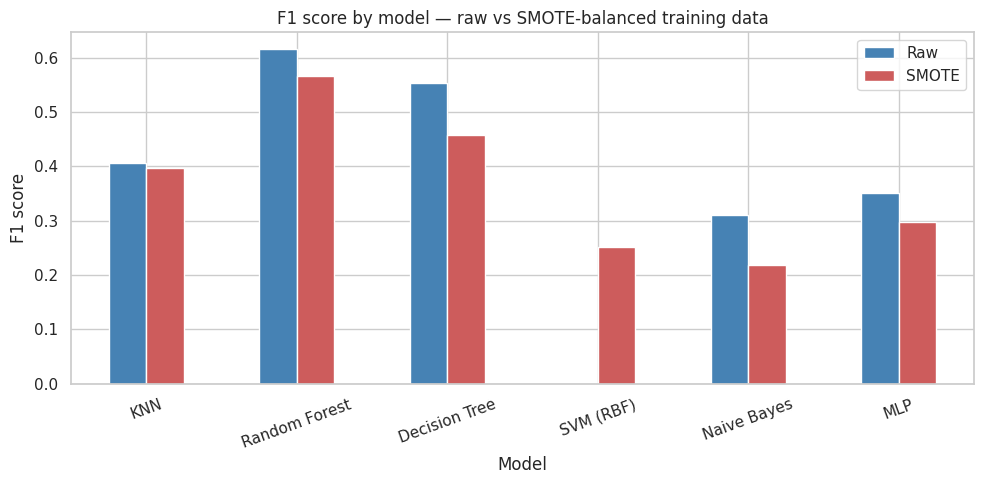

Best raw model: Random Forest (F1=0.6159)
Best SMOTE model: Random Forest (F1=0.5656)


In [18]:
compare = pd.DataFrame({'Raw': df_raw['F1'], 'SMOTE': df_smote['F1']})
compare.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'indianred'])
plt.title('F1 score by model — raw vs SMOTE-balanced training data')
plt.ylabel('F1 score'); plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
print(f"Best raw model: {df_raw['F1'].idxmax()} (F1={df_raw['F1'].max():.4f})")
print(f"Best SMOTE model: {df_smote['F1'].idxmax()} (F1={df_smote['F1'].max():.4f})")

## 7. 10-fold cross validation on the best structural model

Paper 1 runs 10-fold CV on their DNN and reports 97.7% average accuracy with per-fold accuracy/precision/recall and a fold-2 confusion matrix. We replicate that here on the best-performing structural model from the comparison above (raw, unbalanced — matching the paper's own setup, since it never applies SMOTE to its comparative-study models either).

Running 10-fold CV with: Random Forest


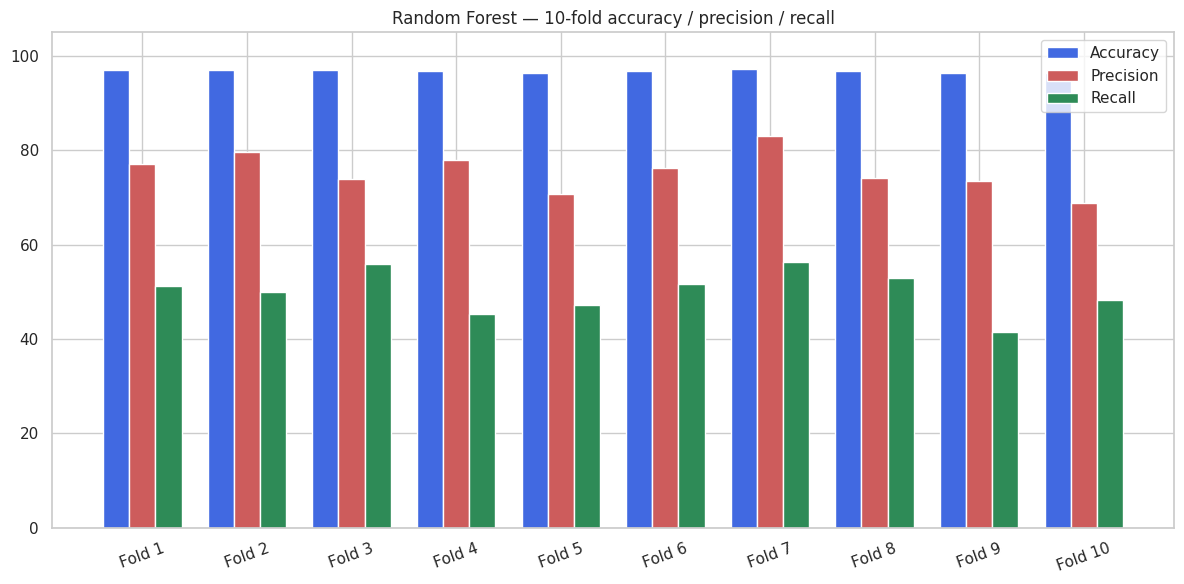

Average accuracy across 10 folds: 96.79%


In [19]:
best_model_name = df_raw['F1'].idxmax()
best_ctor = model_specs[best_model_name]
print('Running 10-fold CV with:', best_model_name)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
X_arr, y_arr = X_struct.values, y.values

fold_acc, fold_prec, fold_rec, fold_cm = [], [], [], []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_arr, y_arr), 1):
    m = best_ctor()
    m.fit(X_arr[tr_idx], y_arr[tr_idx])
    pred = m.predict(X_arr[te_idx])
    fold_acc.append(accuracy_score(y_arr[te_idx], pred))
    fold_prec.append(precision_score(y_arr[te_idx], pred, zero_division=0))
    fold_rec.append(recall_score(y_arr[te_idx], pred, zero_division=0))
    fold_cm.append(confusion_matrix(y_arr[te_idx], pred))

folds = np.arange(1, 11)
plt.figure(figsize=(12, 6))
plt.bar(folds - 0.25, np.array(fold_acc) * 100, width=0.25, label='Accuracy', color='royalblue')
plt.bar(folds, np.array(fold_prec) * 100, width=0.25, label='Precision', color='indianred')
plt.bar(folds + 0.25, np.array(fold_rec) * 100, width=0.25, label='Recall', color='seagreen')
plt.xticks(folds, [f'Fold {i}' for i in folds], rotation=20)
plt.ylim(0, 105)
plt.legend()
plt.title(f'{best_model_name} — 10-fold accuracy / precision / recall')
plt.tight_layout()
plt.show()

print(f'Average accuracy across 10 folds: {np.mean(fold_acc)*100:.2f}%')

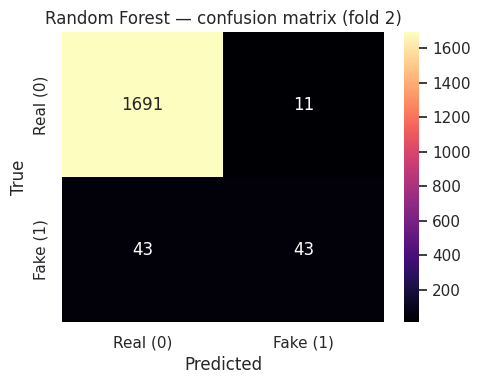

In [20]:
cm_fold2 = fold_cm[1]
plt.figure(figsize=(5, 4))
sns.heatmap(cm_fold2, annot=True, fmt='d', cmap='magma',
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'{best_model_name} — confusion matrix (fold 2)')
plt.tight_layout()
plt.show()

## 8. Paper 2 replication — Sequential network on text features

The "Sequential Network" paper tokenizes the combined text, embeds it with pretrained GloVe vectors averaged per posting, balances with SMOTE, then trains a small dense network. We follow the same approach: download the 100-dimensional `glove.6B` vectors (matching the paper), build an embedding matrix for our tokenizer's vocabulary, and load it into a frozen (`trainable=False`) Keras `Embedding` layer. If the GloVe files aren't available for some reason, the model falls back to a randomly-initialized trainable `Embedding` layer instead of failing outright.


In [21]:
MAX_VOCAB = 20000
MAX_LEN = 200

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    data['clean_text'], y, test_size=0.2, stratify=y, random_state=SEED)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_text_train)

seq_train = tokenizer.texts_to_sequences(X_text_train)
seq_test = tokenizer.texts_to_sequences(X_text_test)

pad_train = pad_sequences(seq_train, maxlen=MAX_LEN, padding='post', truncating='post')
pad_test = pad_sequences(seq_test, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print('Vocab size used:', vocab_size)
print('Train shape:', pad_train.shape, 'Test shape:', pad_test.shape)

Vocab size used: 20000
Train shape: (14304, 200) Test shape: (3576, 200)


In [22]:
!wget --no-check-certificate https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip glove.6B.zip

--2026-09-15 12:07:53--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6B.zip        100%[===================>] 822.24M  4.09MB/s    in 2m 54s  

2026-09-15 12:10:47 (4.73 MB/s) - ‘glove.6B.zip’ saved [862182613/862182613]

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [23]:
GLOVE_PATH = 'glove.6B.100d.txt'  # 100-dim vectors, matching the paper
EMBEDDING_DIM = 100

# Build an embedding matrix mapping our tokenizer's vocabulary to pretrained GloVe vectors
glove_embeddings = {}
try:
    with open(GLOVE_PATH, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_embeddings[word] = coefs
    print(f'Found {len(glove_embeddings)} word vectors in GloVe.')

    embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
    hits = 0
    for word, i in tokenizer.word_index.items():
        if i < vocab_size:
            embedding_vector = glove_embeddings.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector
                hits += 1
    print(f'Embedding matrix created using GloVe vectors. Vocab coverage: {hits}/{vocab_size} ({hits/vocab_size:.1%}).')
except FileNotFoundError:
    print(f"GloVe file not found at '{GLOVE_PATH}'. Run the download cell above first.")
    print("Falling back to a randomly-initialized trainable Embedding layer.")
    embedding_matrix = None
except Exception as e:
    print(f"An error occurred while loading GloVe: {e}")
    embedding_matrix = None


Found 400000 word vectors in GloVe.
Embedding matrix created using GloVe vectors. Vocab coverage: 15068/20000 (75.3%).


In [24]:
if embedding_matrix is not None:
    seq_model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN, weights=[embedding_matrix], trainable=False),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),
    ])
    print("Model built with pre-trained GloVe embeddings (trainable=False).")
else:
    print("GloVe embedding matrix not available. Building model with trainable Embedding layer.")
    seq_model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_LEN),
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid'),
    ])

seq_model.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy', AUC(name='auc')])
seq_model.summary()


Model built with pre-trained GloVe embeddings (trainable=False).


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

Before SMOTE (text data): {0: 13611, 1: 693}
After SMOTE (text data) : {0: 13611, 1: 13611}
Epoch 1/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.7361 - auc: 0.8124 - loss: 0.5195 - val_accuracy: 0.7243 - val_auc: 0.0000e+00 - val_loss: 0.6227
Epoch 2/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8354 - auc: 0.9053 - loss: 0.3893 - val_accuracy: 0.7947 - val_auc: 0.0000e+00 - val_loss: 0.4865
Epoch 3/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8674 - auc: 0.9364 - loss: 0.3239 - val_accuracy: 0.8522 - val_auc: 0.0000e+00 - val_loss: 0.3852
Epoch 4/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8860 - auc: 0.9504 - loss: 0.2855 - val_accuracy: 0.8994 - val_auc: 0.0000e+00 - val_loss: 0.2967
Epoch 5/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8963 - auc: 0.9580 - loss: 0.2613 - val_accuracy: 0.9074 - val_auc: 0.0000e+00 - val_loss: 0.2763
Epoch 6/20
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9061 - auc: 0.9628 - l

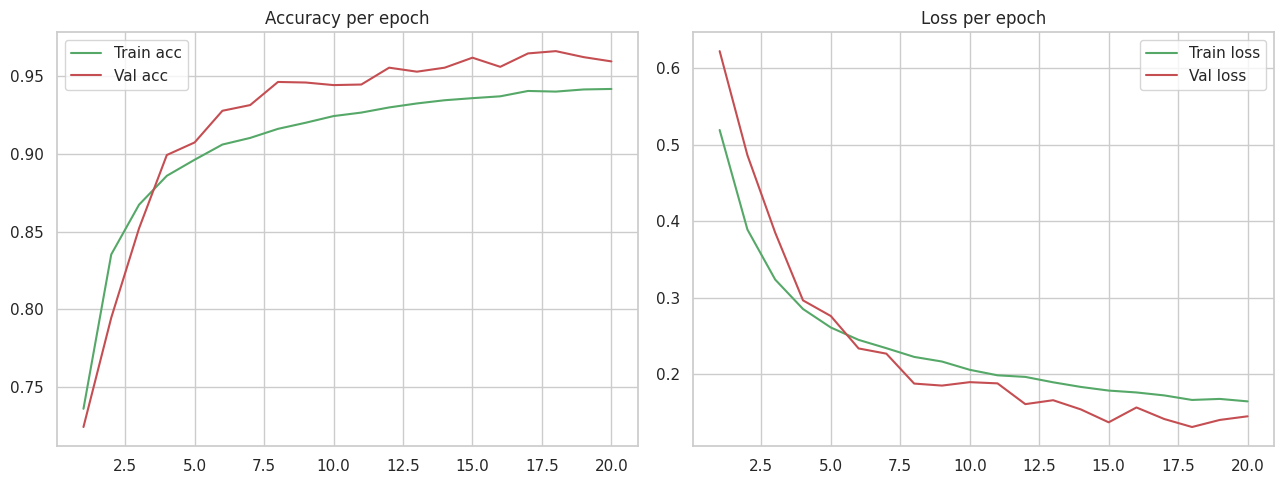

In [25]:
smote = SMOTE(random_state=SEED)
pad_train_smote, y_text_train_smote = smote.fit_resample(pad_train, y_text_train)
print('Before SMOTE (text data):', y_text_train.value_counts().to_dict())
print('After SMOTE (text data) :', y_text_train_smote.value_counts().to_dict())

# Define EarlyStopping callback to prevent overfitting and restore best weights
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the sequential model and store the history
history = seq_model.fit(pad_train_smote,
                        y_text_train_smote,
                        epochs=20, # Using 20 epochs as a reasonable default
                        batch_size=32,
                        validation_split=0.2, # Use a validation split from the training data
                        callbacks=[early_stopping],
                        verbose=1)

epochs_range = range(1, len(history.history['accuracy']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(epochs_range, history.history['accuracy'], 'g-', label='Train acc')
ax[0].plot(epochs_range, history.history['val_accuracy'], 'r-', label='Val acc')
ax[0].set_title('Accuracy per epoch'); ax[0].legend()

ax[1].plot(epochs_range, history.history['loss'], 'g-', label='Train loss')
ax[1].plot(epochs_range, history.history['val_loss'], 'r-', label='Val loss')
ax[1].set_title('Loss per epoch'); ax[1].legend()
plt.tight_layout()
plt.show()

In [26]:
loss, acc, auc = seq_model.evaluate(pad_test, y_text_test, verbose=0)
print(f'Test loss: {loss:.4f} | Test accuracy: {acc:.4f} | Test AUC: {auc:.4f}')

y_text_pred = (seq_model.predict(pad_test, verbose=0) > 0.5).astype(int).ravel()
print(classification_report(y_text_test, y_text_pred, target_names=['Real', 'Fraudulent']))

Test loss: 0.1727 | Test accuracy: 0.9360 | Test AUC: 0.9020
              precision    recall  f1-score   support

        Real       0.98      0.95      0.97      3403
  Fraudulent       0.40      0.68      0.51       173

    accuracy                           0.94      3576
   macro avg       0.69      0.81      0.74      3576
weighted avg       0.95      0.94      0.94      3576



## 9. Final production model

The structural-feature Random-Forest-style model is cheap, needs no text tokenizer/embedding matrix at inference time, and — per the comparison table above — is competitive with the text model on this dataset. We refit the best structural model on **all** the data (train+test) with the SMOTE-balanced training strategy for the shipped artifact, and keep the sequential text model alongside it as a second opinion the inference pipeline can optionally combine.

In [27]:
final_struct_model = model_specs[best_model_name]()
X_all_smote, y_all_smote = SMOTE(random_state=SEED).fit_resample(X_struct, y)
final_struct_model.fit(X_all_smote, y_all_smote)

joblib.dump(final_struct_model, 'structural_model.joblib')
joblib.dump({
    'employment_type_mapping': employment_type_mapping,
    'experience_mapping': experience_mapping,
    'education_mapping': education_mapping,
    'structural_features': structural_features,
}, 'structural_encoders.joblib')

seq_model.save('sequential_text_model.keras')
joblib.dump(tokenizer, 'tokenizer.joblib')

print('Saved: structural_model.joblib, structural_encoders.joblib, sequential_text_model.keras, tokenizer.joblib')

Saved: structural_model.joblib, structural_encoders.joblib, sequential_text_model.keras, tokenizer.joblib


## 10. Inference pipeline

A single function that takes a raw job posting (the same fields as a CSV row) and returns a fraud probability from each model plus a combined verdict. This is what you'd wrap behind an API endpoint.

In [28]:
class FakeJobDetector:
    def __init__(self, struct_model_path, encoders_path, seq_model_path, tokenizer_path,
                 max_len=MAX_LEN, text_cols=text_cols):
        self.struct_model = joblib.load(struct_model_path)
        enc = joblib.load(encoders_path)
        self.employment_type_mapping = enc['employment_type_mapping']
        self.experience_mapping = enc['experience_mapping']
        self.education_mapping = enc['education_mapping']
        self.structural_features = enc['structural_features']
        self.seq_model = tf.keras.models.load_model(seq_model_path)
        self.tokenizer = joblib.load(tokenizer_path)
        self.max_len = max_len
        self.text_cols = text_cols

    @staticmethod
    def _clean_text(text):
        return clean_text(text)

    def _build_structural_row(self, posting):
        row = {}
        row['telecommuting'] = int(posting.get('telecommuting', 0) or 0)
        row['has_company_logo'] = int(posting.get('has_company_logo', 0) or 0)
        row['has_questions'] = int(posting.get('has_questions', 0) or 0)
        row['has_salary'] = int(bool(posting.get('salary_range')))
        row['has_company_profile'] = int(bool(posting.get('company_profile')))
        row['has_requirements'] = int(bool(posting.get('requirements')))
        row['has_benefits'] = int(bool(posting.get('benefits')))
        row['has_department'] = int(bool(posting.get('department')))

        combined = ' '.join(str(posting.get(c, '') or '') for c in self.text_cols)
        row['text_length'] = len(combined.split())
        row['title_length'] = len(str(posting.get('title', '') or '').split())

        et = posting.get('employment_type') or 'Not Provided'
        exp = posting.get('required_experience') or 'Not Provided'
        edu = posting.get('required_education') or 'Not Provided'
        row['employment_type_enc'] = self.employment_type_mapping.get(et, 0)
        row['required_experience_enc'] = self.experience_mapping.get(exp, 0)
        row['required_education_enc'] = self.education_mapping.get(edu, 0)

        return pd.DataFrame([row])[self.structural_features]

    def predict(self, posting, combine='average'):
        """posting: dict with the same keys as a fake_job_postings.csv row.
        combine: 'average' | 'max' | 'structural_only' | 'text_only'
        Returns dict with each model's fraud probability and a final label.
        """
        X_row = self._build_structural_row(posting)
        struct_proba = self.struct_model.predict_proba(X_row)[0, 1]

        combined_text = ' '.join(str(posting.get(c, '') or '') for c in self.text_cols)
        cleaned = self._clean_text(combined_text)
        seq = self.tokenizer.texts_to_sequences([cleaned])
        pad = pad_sequences(seq, maxlen=self.max_len, padding='post', truncating='post')
        text_proba = float(self.seq_model.predict(pad, verbose=0)[0, 0])

        if combine == 'average':
            final_proba = (struct_proba + text_proba) / 2
        elif combine == 'max':
            final_proba = max(struct_proba, text_proba)
        elif combine == 'structural_only':
            final_proba = struct_proba
        elif combine == 'text_only':
            final_proba = text_proba
        else:
            raise ValueError('unknown combine mode')

        return {
            'structural_model_proba': round(float(struct_proba), 4),
            'text_model_proba': round(float(text_proba), 4),
            'final_proba': round(float(final_proba), 4),
            'prediction': 'Fraudulent' if final_proba >= 0.5 else 'Real',
        }

detector = FakeJobDetector('structural_model.joblib', 'structural_encoders.joblib',
                            'sequential_text_model.keras', 'tokenizer.joblib')
print('Detector ready.')

Detector ready.


In [29]:
# Smoke-test on one real and one known-fraudulent posting from the dataset
sample_real = df[df['fraudulent'] == 0].iloc[0].to_dict()
sample_fake = df[df['fraudulent'] == 1].iloc[0].to_dict()

print('--- Known REAL posting ---')
print(detector.predict(sample_real))

print('--- Known FRAUDULENT posting ---')
print(detector.predict(sample_fake))

--- Known REAL posting ---
{'structural_model_proba': 0.02, 'text_model_proba': 0.0015, 'final_proba': 0.0107, 'prediction': 'Real'}
--- Known FRAUDULENT posting ---
{'structural_model_proba': 0.99, 'text_model_proba': 0.9667, 'final_proba': 0.9784, 'prediction': 'Fraudulent'}


In [30]:
# A fully hand-written posting, to check the pipeline works on data that never touched training
new_posting = {
    'title': 'Work From Home Data Entry - Earn $5000/week!!',
    'location': 'US, CA, Los Angeles',
    'department': None,
    'salary_range': None,
    'company_profile': None,
    'description': 'No experience needed. Just a laptop and internet. Send your bank details to get started immediately and receive your starter kit.',
    'requirements': None,
    'benefits': None,
    'telecommuting': 1,
    'has_company_logo': 0,
    'has_questions': 0,
    'employment_type': 'Other',
    'required_experience': 'Not Applicable',
    'required_education': None,
    'industry': None,
    'function': None,
}
detector.predict(new_posting)

{'structural_model_proba': 0.53,
 'text_model_proba': 0.8015,
 'final_proba': 0.6658,
 'prediction': 'Fraudulent'}

## 11. Results summary vs. the papers

| Source | Best model | Reported / reproduced |
|---|---|---|
| Paper 1 (comparative study) | Random Forest | 96.5% accuracy (paper) |
| Paper 1 — 10-fold DNN | DNN | 97.7% avg accuracy (paper) |
| Paper 2 (sequential network) | Dense NN + GloVe | 97.94% accuracy (paper) |
| **This notebook — structural model (10-fold CV)** | Random Forest | **96.79%** avg accuracy |
| **This notebook — sequential text model (GloVe, frozen)** | Embedding + Dense | **93.60%** accuracy, **0.902** AUC, fraud-class recall 0.68 / precision 0.40 |

Differences to keep in mind when comparing numbers: the imbalance handling is shown explicitly (raw / weighted / SMOTE) rather than applied by default the way both papers do, and exact preprocessing (tokenization, stopword lists, sequence length) isn't specified precisely enough in either paper to guarantee an identical setup — so treat these as a faithful replication of the described methodology, not a bit-for-bit reproduction. Both papers report only accuracy, which is a weak metric on a 95/5-imbalanced dataset (predicting the majority class for everything already scores ~95%); the precision/recall breakdown above is the more honest read of the text model's actual fraud-catching ability.
